In [2]:
# Import Dependencies

import os
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras import regularizers
from sklearn.metrics import roc_curve, roc_auc_score, confusion_matrix, precision_recall_fscore_support

In [3]:
# Paths

root = "/kaggle/input/breast-cancer-detection-mri/Breast_Cancer_MRI_Dataset"
IMG_SIZE = (512, 512)
BATCH = 16
SEED = 42
AUTOTUNE = tf.data.AUTOTUNE

In [4]:
# Load dataset

def build_ds(subdir, augment=False, shuffle=False):
    ds = tf.keras.utils.image_dataset_from_directory(
        os.path.join(root, subdir),
        labels="inferred",
        label_mode="int",
        color_mode="rgb",
        batch_size=BATCH,
        image_size=IMG_SIZE,
        shuffle=shuffle,
        seed=SEED
    )

    aug = keras.Sequential([
        layers.RandomFlip("horizontal_and_vertical"),
        layers.RandomRotation(0.05),
        layers.RandomContrast(0.1),
        layers.RandomZoom(0.1)
    ]) if augment else None

    def _map(x, y):
        x = tf.cast(x, tf.float32)
        if aug is not None:
            x = aug(x, training=True)
        return x, y

    return (ds.map(_map, num_parallel_calls=AUTOTUNE)
              .cache()
              .prefetch(AUTOTUNE))

train_ds = build_ds("train", augment=True, shuffle=True)
val_ds   = build_ds("validation", augment=False, shuffle=False)
test_ds  = build_ds("test", augment=False, shuffle=False)

Found 4000 files belonging to 2 classes.
Found 400 files belonging to 2 classes.
Found 400 files belonging to 2 classes.


In [6]:
# Evaluate with best threshold

# Load the model
from tensorflow.keras.models import load_model
model_mobilenetv2small = load_model("/kaggle/input/mnetv3small/tensorflow2/default/1/MOBILENETV3SMALL.keras")

def best_threshold(ds):
    y_true = np.concatenate([y for _, y in ds], axis=0)
    y_prob = model_mobilenetv2small.predict(ds, verbose=0).ravel()
    fpr, tpr, thr = roc_curve(y_true, y_prob)
    youden = tpr - fpr
    return thr[np.argmax(youden)]

thr = best_threshold(val_ds)
print("Best threshold:", thr)

def metrics_at_threshold(ds, thr):
    y_true = np.concatenate([y for _, y in ds], axis=0)
    y_prob = model_mobilenetv2small.predict(ds, verbose=0).ravel()
    y_pred = (y_prob >= thr).astype(int)
    auc = roc_auc_score(y_true, y_prob)
    cm = confusion_matrix(y_true, y_pred)
    prec, rec, f1, _ = precision_recall_fscore_support(y_true, y_pred, average="binary")
    tn, fp, fn, tp = cm.ravel()
    spec = tn / (tn + fp)
    return dict(auc=auc, precision=prec, recall=rec, f1=f1, specificity=spec, cm=cm)

print("Validation metrics:", metrics_at_threshold(val_ds, thr))
print("Test metrics:", metrics_at_threshold(test_ds, thr))

I0000 00:00:1762287686.727066      98 service.cc:148] XLA service 0x786490232570 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1762287686.727810      98 service.cc:156]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1762287686.727828      98 service.cc:156]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1762287687.184236      98 cuda_dnn.cc:529] Loaded cuDNN version 90300
E0000 00:00:1762287688.776083      98 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1762287688.948309      98 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
I0000 00:00:1762287692.161409      98 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most onc

Best threshold: 0.40067193
Validation metrics: {'auc': 0.994725, 'precision': 0.9848484848484849, 'recall': 0.975, 'f1': 0.9798994974874371, 'specificity': 0.985, 'cm': array([[197,   3],
       [  5, 195]])}
Test metrics: {'auc': 0.9765, 'precision': 0.9405940594059405, 'recall': 0.95, 'f1': 0.9452736318407959, 'specificity': 0.94, 'cm': array([[188,  12],
       [ 10, 190]])}


In [7]:
!pip install tensorflow_model_optimization
import tensorflow_model_optimization as tfmot

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 242.5/242.5 kB 4.7 MB/s eta 0:00:00a 0:00:01


In [8]:
# Create the TFLite converter
converter = tf.lite.TFLiteConverter.from_keras_model(model_mobilenetv2small)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.target_spec.supported_types = [tf.float16]

# Convert the model
tflite_quant_model = converter.convert()

Saved artifact at '/tmp/tmpf2y3cem3'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 512, 512, 3), dtype=tf.float32, name='input_layer_2')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  132374254517904: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132374254516176: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132374254516368: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132374254515984: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132374254518096: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132374254515024: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132374254517136: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132374254514640: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132374254515408: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132374254517328: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1323742545167

W0000 00:00:1762287861.664598      37 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1762287861.664637      37 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.
I0000 00:00:1762287861.788223      37 mlir_graph_optimization_pass.cc:401] MLIR V1 optimization pass is not enabled


In [9]:
# Save the quantized model

with open("/kaggle/working/MobileNetV3SmallF16Quantized.tflite", "wb") as f:
    f.write(tflite_quant_model)

In [12]:
# Create the TFLite converter
converter = tf.lite.TFLiteConverter.from_keras_model(model_mobilenetv2small)
converter.optimizations = [tf.lite.Optimize.DEFAULT]

# Convert the model
tflite_quant_model = converter.convert()

Saved artifact at '/tmp/tmphglr359u'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 512, 512, 3), dtype=tf.float32, name='input_layer_2')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  132374254517904: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132374254516176: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132374254516368: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132374254515984: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132374254518096: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132374254515024: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132374254517136: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132374254514640: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132374254515408: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132374254517328: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1323742545167

W0000 00:00:1762288058.495301      37 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1762288058.495335      37 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.


In [13]:
# Save the quantized model

with open("/kaggle/working/MobileNetV3SmallF32Quantized.tflite", "wb") as f:
    f.write(tflite_quant_model)

In [14]:
files = [
    "/kaggle/input/mnetv3small/tensorflow2/default/1/MOBILENETV3SMALL.keras",
    "/kaggle/working/MobileNetV3SmallF32Quantized.tflite",
    "/kaggle/working/MobileNetV3SmallF16Quantized.tflite"
]

for f in files:
    size_mb = os.path.getsize(f) / (1024 * 1024)
    print(f"{f}: {size_mb:.2f} MB")

/kaggle/input/mnetv3small/tensorflow2/default/1/MOBILENETV3SMALL.keras: 11.30 MB
/kaggle/working/MobileNetV3SmallF32Quantized.tflite: 1.06 MB
/kaggle/working/MobileNetV3SmallF16Quantized.tflite: 1.82 MB


In [17]:
from PIL import Image

# Path to your test dataset
test_dir = "/kaggle/input/breast-cancer-detection-mri/Breast_Cancer_MRI_Dataset/test"

# Load images and labels
def load_test_data(test_dir, img_size=(512, 512)):
    images = []
    labels = []
    class_map = {"neg": 0, "pos": 1}

    for class_name in ["neg", "pos"]:
        class_path = os.path.join(test_dir, class_name)
        for img_file in os.listdir(class_path):
            img_path = os.path.join(class_path, img_file)
            img = Image.open(img_path).convert("RGB")
            img = img.resize(img_size)
            img_array = np.array(img, dtype=np.float32) / 255.0 
            images.append(img_array)
            labels.append(class_map[class_name])
    
    return np.array(images), np.array(labels)

In [18]:
test_images, test_labels = load_test_data(test_dir)

### Dynamic Range Quantized Model

In [25]:
# Function to get probabilities from TFLite model
def tflite_predict(interpreter, dataset):
    input_index = interpreter.get_input_details()[0]["index"]
    output_index = interpreter.get_output_details()[0]["index"]
    y_true, y_prob = [], []

    for x_batch, y_batch in dataset:
        for img, label in zip(x_batch, y_batch):
            img = np.expand_dims(img, axis=0).astype(np.float32)
            interpreter.set_tensor(input_index, img)
            interpreter.invoke()
            output = interpreter.get_tensor(output_index)[0]

            # Handle 2-class vs 1-class output
            if output.shape[0] == 2:
                prob = tf.nn.softmax(output).numpy()[1]
            else:
                prob = output[0]

            y_true.append(label)
            y_prob.append(prob)

    return np.array(y_true), np.array(y_prob)


# Load TFLite model
interpreter = tf.lite.Interpreter(model_path="/kaggle/working/MobileNetV3SmallF32Quantized.tflite")
interpreter.allocate_tensors()


# Find best threshold (Youden’s J statistic) 
def best_threshold_tflite(interpreter, val_ds):
    y_true, y_prob = tflite_predict(interpreter, val_ds)
    fpr, tpr, thr = roc_curve(y_true, y_prob)
    youden = tpr - fpr
    return thr[np.argmax(youden)], y_true, y_prob


thr, y_true_val, y_prob_val = best_threshold_tflite(interpreter, val_ds)
print("Best threshold:", thr)


# Compute metrics at threshold 
def metrics_at_threshold_tflite(interpreter, ds, thr):
    y_true, y_prob = tflite_predict(interpreter, ds)
    y_pred = (y_prob >= thr).astype(int)

    auc = roc_auc_score(y_true, y_prob)
    cm = confusion_matrix(y_true, y_pred)
    prec, rec, f1, _ = precision_recall_fscore_support(y_true, y_pred, average="binary", zero_division=0)
    tn, fp, fn, tp = cm.ravel()
    spec = tn / (tn + fp)

    return dict(auc=auc, precision=prec, recall=rec, f1=f1, specificity=spec, cm=cm)


print("Validation metrics:", metrics_at_threshold_tflite(interpreter, val_ds, thr))
print("Test metrics:", metrics_at_threshold_tflite(interpreter, test_ds, thr))

Best threshold: 0.6525141
Validation metrics: {'auc': 0.987275, 'precision': 1.0, 'recall': 0.925, 'f1': 0.961038961038961, 'specificity': 1.0, 'cm': array([[200,   0],
       [ 15, 185]])}
Test metrics: {'auc': 0.9721249999999999, 'precision': 0.9680851063829787, 'recall': 0.91, 'f1': 0.9381443298969071, 'specificity': 0.97, 'cm': array([[194,   6],
       [ 18, 182]])}


Best threshold: 0.6525141

Test metrics:
auc: 0.9721
precision: 0.9681
recall: 0.9100
f1: 0.9381
specificity: 0.9700


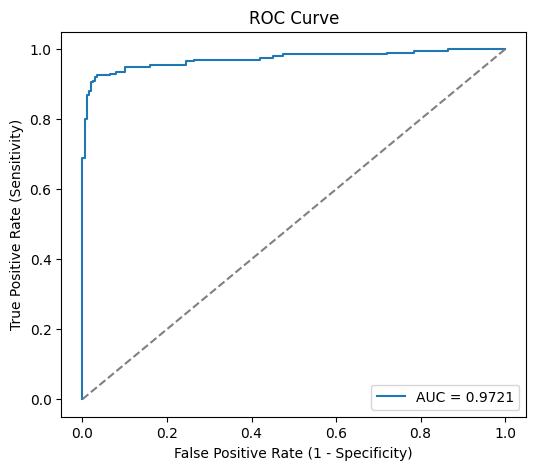

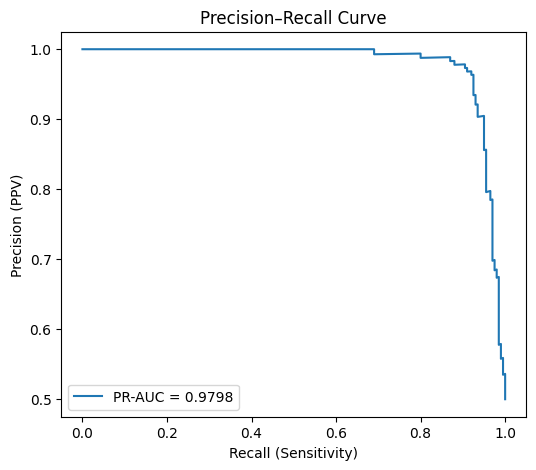

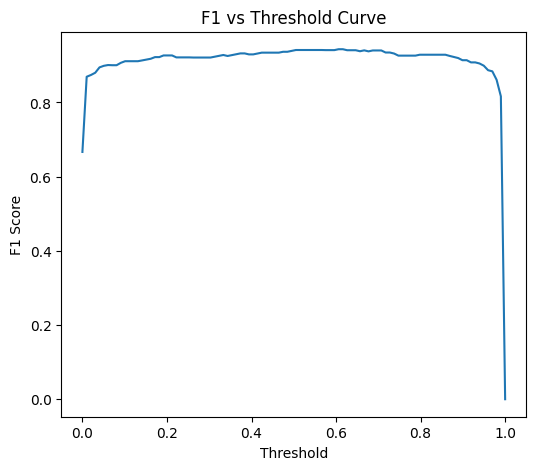

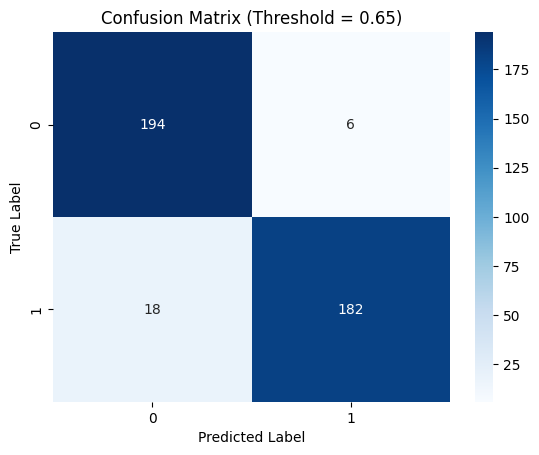

ROC-AUC: 0.9721
PR-AUC: 0.9798


In [21]:
from sklearn.metrics import (
    roc_curve, roc_auc_score, precision_recall_curve,
    average_precision_score, f1_score, confusion_matrix,
    precision_recall_fscore_support
)
import matplotlib.pyplot as plt
import seaborn as sns


# Get predictions from TFLite model
def tflite_predict(interpreter, dataset):
    input_index = interpreter.get_input_details()[0]["index"]
    output_index = interpreter.get_output_details()[0]["index"]
    y_true, y_prob = [], []

    for x_batch, y_batch in dataset:
        for img, label in zip(x_batch, y_batch):
            img = np.expand_dims(img, axis=0).astype(np.float32)
            interpreter.set_tensor(input_index, img)
            interpreter.invoke()
            output = interpreter.get_tensor(output_index)[0]

            # Handle 2-class vs 1-class model outputs
            if output.shape[0] == 2:
                prob = tf.nn.softmax(output).numpy()[1]
            else:
                prob = output[0]

            y_true.append(label)
            y_prob.append(prob)

    return np.array(y_true), np.array(y_prob)


# Find best threshold using Youden’s J statistic
def best_threshold_tflite(interpreter, val_ds):
    y_true, y_prob = tflite_predict(interpreter, val_ds)
    fpr, tpr, thr = roc_curve(y_true, y_prob)
    youden = tpr - fpr
    best_thr = thr[np.argmax(youden)]
    return best_thr, y_true, y_prob


# Compute metrics at threshold 
def metrics_at_threshold_tflite(interpreter, ds, thr):
    y_true, y_prob = tflite_predict(interpreter, ds)
    y_pred = (y_prob >= thr).astype(int)

    auc = roc_auc_score(y_true, y_prob)
    cm = confusion_matrix(y_true, y_pred)
    prec, rec, f1, _ = precision_recall_fscore_support(y_true, y_pred, average="binary", zero_division=0)
    tn, fp, fn, tp = cm.ravel()
    spec = tn / (tn + fp)

    return dict(auc=auc, precision=prec, recall=rec, f1=f1, specificity=spec, cm=cm, 
                y_true=y_true, y_prob=y_prob)


# Plot all diagnostic curves
def plot_medical_curves(y_true, y_prob, threshold=0.5):
    # ROC Curve
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    roc_auc = roc_auc_score(y_true, y_prob)
    plt.figure(figsize=(6,5))
    plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
    plt.plot([0,1],[0,1],'--',color='gray')
    plt.title("ROC Curve")
    plt.xlabel("False Positive Rate (1 - Specificity)")
    plt.ylabel("True Positive Rate (Sensitivity)")
    plt.legend()
    plt.show()

    # Precision–Recall Curve
    precisions, recalls, _ = precision_recall_curve(y_true, y_prob)
    pr_auc = average_precision_score(y_true, y_prob)
    plt.figure(figsize=(6,5))
    plt.plot(recalls, precisions, label=f"PR-AUC = {pr_auc:.4f}")
    plt.xlabel("Recall (Sensitivity)")
    plt.ylabel("Precision (PPV)")
    plt.title("Precision–Recall Curve")
    plt.legend()
    plt.show()

    # F1 vs Threshold Curve
    thresholds = np.linspace(0, 1, 100)
    f1s = [f1_score(y_true, (y_prob >= t).astype(int)) for t in thresholds]
    plt.figure(figsize=(6,5))
    plt.plot(thresholds, f1s)
    plt.xlabel("Threshold")
    plt.ylabel("F1 Score")
    plt.title("F1 vs Threshold Curve")
    plt.show()

    # Confusion Matrix
    y_pred = (y_prob >= threshold).astype(int)
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title(f"Confusion Matrix (Threshold = {threshold:.2f})")
    plt.show()

    print(f"ROC-AUC: {roc_auc:.4f}")
    print(f"PR-AUC: {pr_auc:.4f}")


# Load TFLite model
interpreter = tf.lite.Interpreter(model_path="/kaggle/working/MobileNetV3SmallF32Quantized.tflite")
interpreter.allocate_tensors()


# Find best threshold using validation set
thr, y_true_val, y_prob_val = best_threshold_tflite(interpreter, val_ds)
print("Best threshold:", thr)

# Compute metrics for test set
test_metrics = metrics_at_threshold_tflite(interpreter, test_ds, thr)
print("\nTest metrics:")
for k, v in test_metrics.items():
    if k not in ["y_true", "y_prob", "cm"]:
        print(f"{k}: {v:.4f}")

# Plot all diagnostic curves for test set
plot_medical_curves(test_metrics["y_true"], test_metrics["y_prob"], threshold=thr)

### 16 bit quantized model

In [24]:
# Function to get probabilities from TFLite model
def tflite_predict(interpreter, dataset):
    input_index = interpreter.get_input_details()[0]["index"]
    output_index = interpreter.get_output_details()[0]["index"]
    y_true, y_prob = [], []

    for x_batch, y_batch in dataset:
        for img, label in zip(x_batch, y_batch):
            img = np.expand_dims(img, axis=0).astype(np.float32)
            interpreter.set_tensor(input_index, img)
            interpreter.invoke()
            output = interpreter.get_tensor(output_index)[0]

            # Handle 2-class vs 1-class output
            if output.shape[0] == 2:
                prob = tf.nn.softmax(output).numpy()[1]
            else:
                prob = output[0]

            y_true.append(label)
            y_prob.append(prob)

    return np.array(y_true), np.array(y_prob)


# Load TFLite model
interpreter = tf.lite.Interpreter(model_path="/kaggle/working/MobileNetV3SmallF16Quantized.tflite")
interpreter.allocate_tensors()


# Find best threshold (Youden’s J statistic) 
def best_threshold_tflite(interpreter, val_ds):
    y_true, y_prob = tflite_predict(interpreter, val_ds)
    fpr, tpr, thr = roc_curve(y_true, y_prob)
    youden = tpr - fpr
    return thr[np.argmax(youden)], y_true, y_prob


thr, y_true_val, y_prob_val = best_threshold_tflite(interpreter, val_ds)
print("Best threshold:", thr)


# Compute metrics at threshold 
def metrics_at_threshold_tflite(interpreter, ds, thr):
    y_true, y_prob = tflite_predict(interpreter, ds)
    y_pred = (y_prob >= thr).astype(int)

    auc = roc_auc_score(y_true, y_prob)
    cm = confusion_matrix(y_true, y_pred)
    prec, rec, f1, _ = precision_recall_fscore_support(y_true, y_pred, average="binary", zero_division=0)
    tn, fp, fn, tp = cm.ravel()
    spec = tn / (tn + fp)

    return dict(auc=auc, precision=prec, recall=rec, f1=f1, specificity=spec, cm=cm)


print("Validation metrics:", metrics_at_threshold_tflite(interpreter, val_ds, thr))
print("Test metrics:", metrics_at_threshold_tflite(interpreter, test_ds, thr))

Best threshold: 0.33087298
Validation metrics: {'auc': 0.99425, 'precision': 0.9846153846153847, 'recall': 0.96, 'f1': 0.9721518987341772, 'specificity': 0.985, 'cm': array([[197,   3],
       [  8, 192]])}
Test metrics: {'auc': 0.977575, 'precision': 0.9310344827586207, 'recall': 0.945, 'f1': 0.9379652605459057, 'specificity': 0.93, 'cm': array([[186,  14],
       [ 11, 189]])}


Best threshold: 0.33087298

Test metrics:
auc: 0.9776
precision: 0.9310
recall: 0.9450
f1: 0.9380
specificity: 0.9300


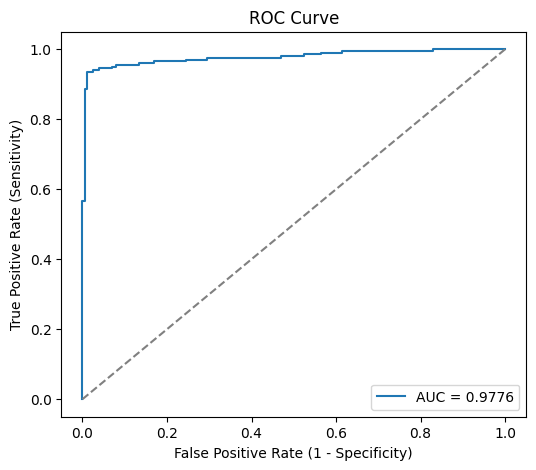

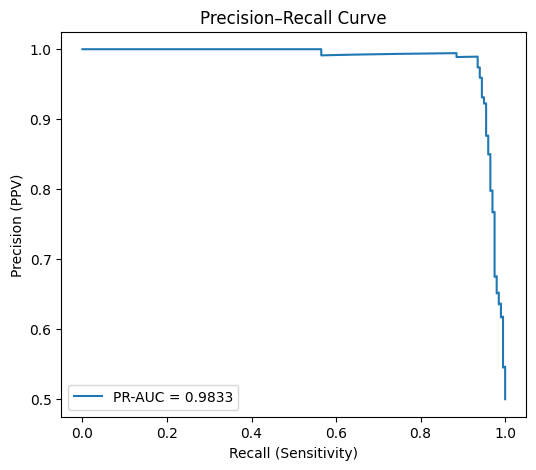

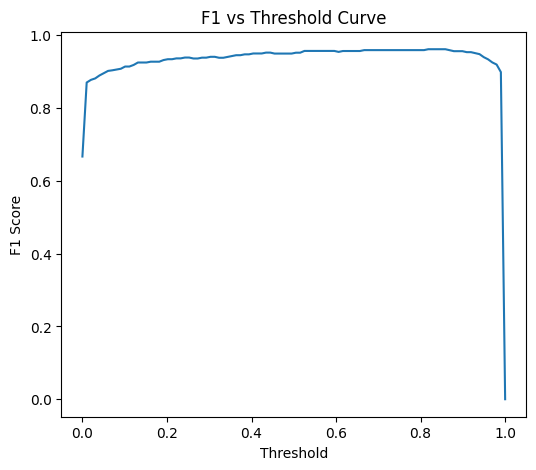

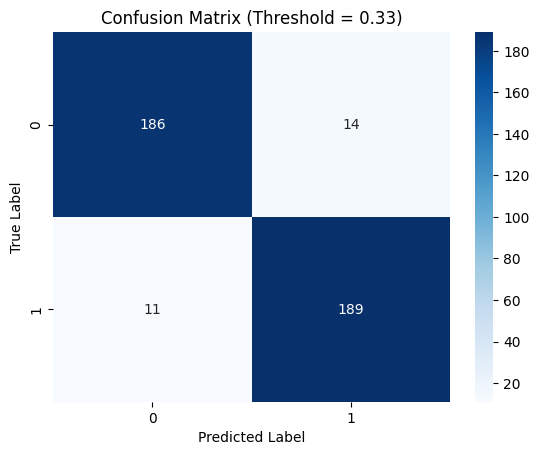

ROC-AUC: 0.9776
PR-AUC: 0.9833


In [22]:
from sklearn.metrics import (
    roc_curve, roc_auc_score, precision_recall_curve,
    average_precision_score, f1_score, confusion_matrix,
    precision_recall_fscore_support
)
import matplotlib.pyplot as plt
import seaborn as sns


# Get predictions from TFLite model
def tflite_predict(interpreter, dataset):
    input_index = interpreter.get_input_details()[0]["index"]
    output_index = interpreter.get_output_details()[0]["index"]
    y_true, y_prob = [], []

    for x_batch, y_batch in dataset:
        for img, label in zip(x_batch, y_batch):
            img = np.expand_dims(img, axis=0).astype(np.float32)
            interpreter.set_tensor(input_index, img)
            interpreter.invoke()
            output = interpreter.get_tensor(output_index)[0]

            # Handle 2-class vs 1-class model outputs
            if output.shape[0] == 2:
                prob = tf.nn.softmax(output).numpy()[1]
            else:
                prob = output[0]

            y_true.append(label)
            y_prob.append(prob)

    return np.array(y_true), np.array(y_prob)


# Find best threshold using Youden’s J statistic
def best_threshold_tflite(interpreter, val_ds):
    y_true, y_prob = tflite_predict(interpreter, val_ds)
    fpr, tpr, thr = roc_curve(y_true, y_prob)
    youden = tpr - fpr
    best_thr = thr[np.argmax(youden)]
    return best_thr, y_true, y_prob


# Compute metrics at threshold 
def metrics_at_threshold_tflite(interpreter, ds, thr):
    y_true, y_prob = tflite_predict(interpreter, ds)
    y_pred = (y_prob >= thr).astype(int)

    auc = roc_auc_score(y_true, y_prob)
    cm = confusion_matrix(y_true, y_pred)
    prec, rec, f1, _ = precision_recall_fscore_support(y_true, y_pred, average="binary", zero_division=0)
    tn, fp, fn, tp = cm.ravel()
    spec = tn / (tn + fp)

    return dict(auc=auc, precision=prec, recall=rec, f1=f1, specificity=spec, cm=cm, 
                y_true=y_true, y_prob=y_prob)


# Plot all diagnostic curves
def plot_medical_curves(y_true, y_prob, threshold=0.5):
    # ROC Curve
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    roc_auc = roc_auc_score(y_true, y_prob)
    plt.figure(figsize=(6,5))
    plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
    plt.plot([0,1],[0,1],'--',color='gray')
    plt.title("ROC Curve")
    plt.xlabel("False Positive Rate (1 - Specificity)")
    plt.ylabel("True Positive Rate (Sensitivity)")
    plt.legend()
    plt.show()

    # Precision–Recall Curve
    precisions, recalls, _ = precision_recall_curve(y_true, y_prob)
    pr_auc = average_precision_score(y_true, y_prob)
    plt.figure(figsize=(6,5))
    plt.plot(recalls, precisions, label=f"PR-AUC = {pr_auc:.4f}")
    plt.xlabel("Recall (Sensitivity)")
    plt.ylabel("Precision (PPV)")
    plt.title("Precision–Recall Curve")
    plt.legend()
    plt.show()

    # F1 vs Threshold Curve
    thresholds = np.linspace(0, 1, 100)
    f1s = [f1_score(y_true, (y_prob >= t).astype(int)) for t in thresholds]
    plt.figure(figsize=(6,5))
    plt.plot(thresholds, f1s)
    plt.xlabel("Threshold")
    plt.ylabel("F1 Score")
    plt.title("F1 vs Threshold Curve")
    plt.show()

    # Confusion Matrix
    y_pred = (y_prob >= threshold).astype(int)
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title(f"Confusion Matrix (Threshold = {threshold:.2f})")
    plt.show()

    print(f"ROC-AUC: {roc_auc:.4f}")
    print(f"PR-AUC: {pr_auc:.4f}")


# Load TFLite model
interpreter = tf.lite.Interpreter(model_path="/kaggle/working/MobileNetV3SmallF16Quantized.tflite")
interpreter.allocate_tensors()


# Find best threshold using validation set
thr, y_true_val, y_prob_val = best_threshold_tflite(interpreter, val_ds)
print("Best threshold:", thr)

# Compute metrics for test set
test_metrics = metrics_at_threshold_tflite(interpreter, test_ds, thr)
print("\nTest metrics:")
for k, v in test_metrics.items():
    if k not in ["y_true", "y_prob", "cm"]:
        print(f"{k}: {v:.4f}")

# Plot all diagnostic curves for test set
plot_medical_curves(test_metrics["y_true"], test_metrics["y_prob"], threshold=thr)